Practical Exam | Set A  
---

Part A – Theory
---
1. Explain Mean, Median, and Mode with a real-life example.

Mean is the average of all values obtained by dividing the sum of values by the total number of values. Median is the middle value when data is arranged in ascending or descending order. Mode is the value that occurs most frequently in a dataset. For example, if five students score 40, 50, 60, 60, and 90, then Mean = 60, Median = 60, and Mode = 60.

2. What is the difference between Variance and Standard Deviation?

Variance measures how far data points are spread from the mean and is calculated as the average squared deviation from the mean. Standard Deviation is the square root of variance and is expressed in the same unit as the original data. Variance is useful for mathematical calculations, while standard deviation is easier to interpret in real-world situations.

3. Define Normal Distribution and give one practical use case.

A Normal Distribution is a symmetric, bell-shaped probability distribution where most values are concentrated around the mean. The mean, median, and mode are equal in a perfectly normal distribution. A practical use case is analyzing students' exam scores, where most students score near the average and fewer students score extremely high or low.

4. Explain Skewness and Kurtosis in simple words.

Skewness measures the asymmetry of a data distribution. Positive skewness means the tail is longer on the right side, while negative skewness means the tail is longer on the left side. Kurtosis measures how peaked or flat a distribution is compared to a normal distribution. High kurtosis indicates more extreme values or outliers.

5. What is Probability? Differentiate between Empirical vs Theoretical Probability with examples.

Probability is the measure of how likely an event is to occur, ranging from 0 to 1. Theoretical Probability is based on mathematical reasoning; for example, the probability of getting a head when tossing a fair coin is 1/2. Empirical Probability is based on actual observations; for example, if a coin is tossed 100 times and heads appear 55 times, the empirical probability of heads is 55/100 = 0.55.

6. Explain Independent vs Dependent Events with one example each.

Independent Events are events where the occurrence of one event does not affect the other. For example, tossing a coin and rolling a dice are independent events. Dependent Events are events where one event influences the outcome of another. For example, drawing two cards from a deck without replacement is dependent because the first card affects the probability of the second card.

7. What is the intuition of Bayes Theorem in daily life?

Bayes Theorem helps us update probabilities when new information becomes available. It combines prior knowledge with new evidence to make better predictions. For example, if weather forecasts predict rain and dark clouds appear, Bayes Theorem helps increase our belief that it will rain.

8. Explain Eigenvalue and Eigenvector in simple terms.

An Eigenvector is a special vector that changes only in magnitude and not in direction when a transformation is applied. The Eigenvalue indicates how much the eigenvector is stretched or compressed during the transformation. In data science, eigenvalues and eigenvectors are used in techniques like Principal Component Analysis (PCA) for dimensionality reduction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


In [2]:
df = pd.read_csv("students_scores.csv")
print(df.head())

  Student_ID  Age  Math_Score  Science_Score  English_Score  Hours_Studied  \
0     S00001   23         100            100             90            8.4   
1     S00002   20          90             71             79            7.9   
2     S00003   21          82             95             90            6.2   
3     S00004   23         100             97            100            9.6   
4     S00005   19          26             49             64            2.8   

   Pass_Fail  
0          1  
1          1  
2          1  
3          1  
4          1  


Step 1: Measures of Central Tendency & Dispersion
---
1. Calculate Mean, Median, Mode of Math_Score
---

In [3]:
mean_math = df['Math_Score'].mean()
median_math = df['Math_Score'].median()
mode_math = df['Math_Score'].mode()[0]

print("Mean:", mean_math)
print("Median:", median_math)
print("Mode:", mode_math)

Mean: 67.6074
Median: 68.5
Mode: 100


2. Find Range, Variance, Standard Deviation of Science_Score
---

In [ ]:
range_science = df['Science_Score'].max() - df['Science_Score'].min()
variance_science = df['Science_Score'].var()
std_science = df['Science_Score'].std()

print("Range:", range_science)
print("Variance:", variance_science)
print("Standard Deviation:", std_science)

Range: 99
Variance: 459.6795358671735
Standard Deviation: 21.4401384292913


Step 2: Probability Basics
---
1. Probability of Students Passing
---

In [5]:
pass_probability = (df['Pass_Fail'] == 1).mean()
print("Probability of Passing =", pass_probability)

Probability of Passing = 0.917


2. Create Contingency Table
---

In [6]:
df['Hours_GT_5'] = df['Hours_Studied'] > 5

contingency_table = pd.crosstab(
    df['Pass_Fail'],
    df['Hours_GT_5']
)

print(contingency_table)

Hours_GT_5  False  True 
Pass_Fail               
0             415      0
1            1900   2685


3. Conditional Probability
---

In [7]:
conditional_prob = (
    df[df['Hours_Studied'] > 5]['Pass_Fail']
    .mean()
)
print("P(Pass | Hours > 5) =", conditional_prob)

P(Pass | Hours > 5) = 1.0


Step 3: Distribution & Visualization
---
1. Histogram & Normal Curve for Math_Score
---

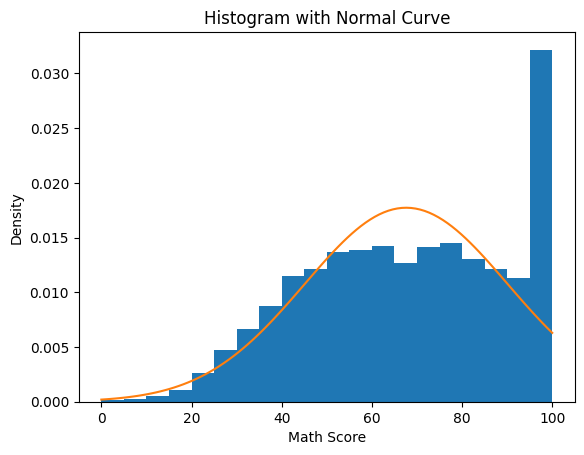

In [8]:
plt.hist(df['Math_Score'],
         bins=20,
         density=True)

mu = df['Math_Score'].mean()
sigma = df['Math_Score'].std()

x = np.linspace(
    df['Math_Score'].min(),
    df['Math_Score'].max(),
    100
)

plt.plot(
    x,
    stats.norm.pdf(x, mu, sigma)
)

plt.title("Histogram with Normal Curve")
plt.xlabel("Math Score")
plt.ylabel("Density")
plt.show()

2. Skewness & Kurtosis of Science_Score
---

In [9]:
skewness = stats.skew(df['Science_Score'])
kurtosis = stats.kurtosis(df['Science_Score'])

print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

Skewness: -0.218523716711186
Kurtosis: -0.847045120822087


3. Q-Q Plot for English_Score
---

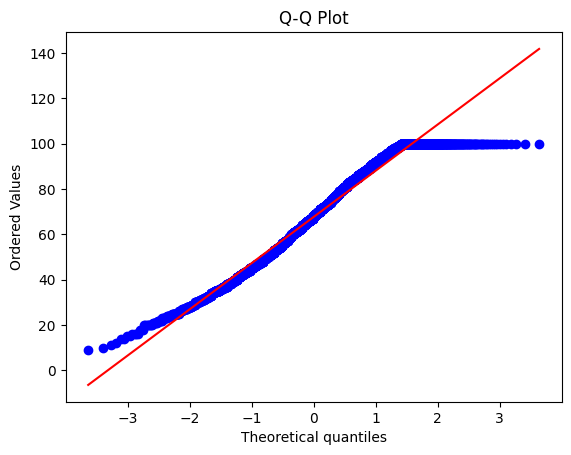

In [10]:
stats.probplot(
    df['English_Score'],
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot")
plt.show()

Step 4: Linear Algebra Mini Task
---
1. Represent First 5 Students as Vectors
---

In [11]:
math_vector = df['Math_Score'].head(5).values
science_vector = df['Science_Score'].head(5).values

print("Math Vector =", math_vector)
print("Science Vector =", science_vector)

Math Vector = [100  90  82 100  26]
Science Vector = [100  71  95  97  49]


2. Dot Product
---

In [12]:
dot_product = np.dot(
    math_vector,
    science_vector
)

print("Dot Product =", dot_product)

Dot Product = 35154


3. Norm 1 and Norm 2
---

In [13]:
norm1 = np.linalg.norm(
    math_vector,
    ord=1
)

norm2 = np.linalg.norm(
    math_vector,
    ord=2
)

print("L1 Norm =", norm1)
print("L2 Norm =", norm2)

L1 Norm = 398.0
L2 Norm = 188.41443681416771


4. Angle Between Two Vectors
---

In [14]:
cos_theta = np.dot(
    math_vector,
    science_vector) / (np.linalg.norm(math_vector) * np.linalg.norm(science_vector)
)
angle = np.degrees(
    np.arccos(cos_theta)
)

print("Angle =", angle)

Angle = 9.919533171713399


Key Insights from the Dataset
---
1. Students who study more than 5 hours have a significantly higher probability of passing compared to students who study less than 5 hours.
2. The Math_Score distribution approximately follows a normal distribution, indicating that most students score around the average range.
3. The Science_Score standard deviation shows moderate variability, meaning student performance differs but is not extremely scattered.
4. The angle between the Math and Science score vectors is close to 0°, suggesting a strong positive relationship between performance in both subjects.
5. Students with higher study hours generally achieve better scores in Math, Science, and English, leading to a higher pass rate.